# AgentCore Runtime with access to VPC resources

This basic sample shows how to configure AgentCore Runtime to access resources in a VPC. 

The sample deploys a web server that echoes the payload received via a `POST /invocations` together with some additional metadata. This server is deployed in the private subnet of a VPC. This is our VPC resource, and is accessible via a service name `echo.agentcore.local`

The AgentCore Runtime is then configured with VPC networking in the same subnets in which the resource is deployed. The Runtime send the payload received on invocation to the echo API and sends it back. Note that the code we deploy to the Runtime ([agent/main.py](agent/main.py))is not an agent, nor uses any LLM. It uses the `bedrock-agentcore` SDK to expose the correct API, but simply forward the payload to the echo service deployed in Fargate and return the response as-is to the caller.

![architecture diagram](<Diagram 1.svg>)

## Deployment

Use the provided CDK to create the VPC, subnets, security groups, Cloud Map and the Fargate service.

```bash
npm install
npx cdk deploy
```

After deployment, you should see outputs similar to the following:

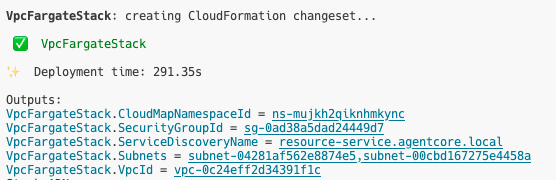

Take note of the SecurityGroupId and Subnets and replace the placeholder in the following cell and then execute the cell.

In [ ]:
%%writefile .env
SUBNETS='subnet-,subnet-'
SECURITY_GROUPS='sg-'

In [ ]:
from bedrock_agentcore_starter_toolkit import Runtime
import boto3
import dotenv
import os

dotenv.load_dotenv(override=True)

session = boto3.Session(region_name="eu-west-1")

region = session.region_name

print(f"Region: {region}")

agentcore_runtime = Runtime()

The following code creates the runtime configuration.

In [ ]:
response = agentcore_runtime.configure(
    entrypoint="agent/main.py",
    auto_create_execution_role=True,
    deployment_type="container",
    runtime_type="PYTHON_3_13",
    auto_create_ecr=True,
    requirements_file="agent/requirements.txt",
    region=region,
    vpc_enabled=True,
    vpc_security_groups=[os.environ["SECURITY_GROUPS"]],
    vpc_subnets=os.environ["SUBNETS"].split(","),
    memory_mode="NO_MEMORY",
    agent_name="agent_in_vpc",
)
print(response)

Deploy the AgentCore runtime. You need to pass the service url of the Fargate container as `API_URL` env var to the runtime.

In [ ]:
agentcore_runtime.launch(
    auto_update_on_conflict=True,
    local_build=True,
    env_vars={"API_URL": "echo.agentcore.local"},
)

In [ ]:
print(agentcore_runtime.invoke({"message": "hello"})["response"])

## Cleanup

To cleanup the resources you deployed run:

```bash
npx cdk destroy
```

In [ ]:
agentcore_runtime.destroy()